[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/drive/1nTrfYonAeupFocIUkbdMOfwRrPbuu1mu)

# **Homework Assignment: Principal Component Analysis (PCA) on 3D Clustered Data**

-------------------------------

You are provided with a dataset containing 3-dimensional data points from three distinct classes. The dataset can be downloaded from the following link:

**[PCA Three Clusters Dataset](https://github.com/SzymonNowakowski/Machine-Learning-2025L/blob/master/PCA_three_clusters_data.csv)**

Each data point is represented by three continuous features $(x, y, z)$ and belongs to one of three clusters (three groups).

## **Primary Question**

**Perform PCA on the provided dataset to find the two principal components and visualize the data in a 2D plot using these components.**

- Compare this PCA plot with the following 2D plots of the original data:
  - $x$ vs. $y$
  - $x$ vs. $z$
  - $y$ vs. $z$

**Does PCA improve the separation of data points from different clusters compared to the original feature spaces? Explain why.**



## **Secondary Question**

Remember: before applying PCA, **standardize** the data so that each feature has a mean of 0 and a variance of 1.

**Why is standardization necessary before applying PCA?**

- Explain how differences in scale among features can impact the principal component directions.

## **Task & Deliverables**

1. **Colab Notebook**  
   - Create a **Colab notebook** that:
     - Performs PCA on the dataset and visualizes the first two principal components in a 2D scatter plot.
     - Includes separate 2D scatter plots for the original feature pairs: $(x, y)$, $(x, z)$, and $(y, z)$.
     - Clearly **answers** both the **primary** and **secondary** questions.
     - Uses Python code to perform PCA, standardize the data, and generate the required plots.
   - To answer the primary question, you may consider creating additional visualizations or charts beyond those listed above. For example, some students might choose to explore a 3D plot of the data. Feel free to experiment with different approaches.

2. **Publish on GitHub**  
   - Place the Colab notebook in your **GitHub repository** for this course.
   - In your repository’s **README**, add a **link** to the notebook and include an **“Open in Colab”** badge in your notebook, so it can be launched directly from GitHub.






In [ ]:
# Na początku przeprowadzę analizę "na piechotę" z wykorzystaniem numpy i rozkładu SVD

import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO

# Link RAW do pliku CSV na GitHubie
url = "https://raw.githubusercontent.com/SzymonNowakowski/Machine-Learning-2025L/master/PCA_three_clusters_data.csv"

# Pobieram plik CSV z internetu
response = requests.get(url)
response.raise_for_status()  # sprawdza, czy pobieranie się powiodło

# Wczytuję dane do numpy
dane = np.loadtxt(StringIO(response.text), delimiter=',', skiprows=1)

# Rozdzielam dane na macierz cech x, y, z oraz etykiety klas
X = dane[:, :3]
y = dane[:, 3]

# Dodatkowe tablice dla wygody rysowania
x_points = dane[:, 0]
y_points = dane[:, 1]
z_points = dane[:, 2]


#Teraz mogę przeprowadzić analizę PCA tak samo jak w przykładzie opisanym w notebooku do zajęć
# First, center X
X = X - np.mean(X, axis=0)

# And standardize it (it is always a good practice, so each dimension is treated as equally important)
X = X / np.std(X, axis=0)

# Perform Singular Value Decomposition
U, Sigma, VT = np.linalg.svd(X)

# Convert Sigma into a full diagonal matrix
Sigma_full = np.zeros((X.shape[0], X.shape[1]))
np.fill_diagonal(Sigma_full, Sigma)

variance_estimators = (Sigma ** 2) / (X.shape[0] - 1)

XV = U @ Sigma_full

print("\nV^T, having the principal directions in ROWS(!)\n")
print(VT)

#print("\nX projected on V (first 5 rows)\n")
#print(XV[:5,:])
print("\nVariance estimators\n")
print(variance_estimators)
print("\nExplained percentage variance\n")
print(variance_estimators / sum(variance_estimators))
print("\nCumulative explained percentage variance\n")
print(np.cumsum(variance_estimators / sum(variance_estimators)))



V^T, having the principal directions in ROWS(!)

[[-0.72005783 -0.56946     0.39652494]
 [ 0.02368275 -0.59126692 -0.80612813]
 [ 0.69350981 -0.57106806  0.43923275]]

Variance estimators

[1.04515213 1.0066104  0.95827091]

Explained percentage variance

[0.34722276 0.33441835 0.31835889]

Cumulative explained percentage variance

[0.34722276 0.68164111 1.        ]


In [13]:
#To samo, ale z wykorzystaniem gotowych pakietów pythona do PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# wracam do poprzednio wczytanych danyc, nieprzeskalowanych, rozpoczynamy całą analizę od nowa
# Rozdzielam dane na macierz cech x, y, z oraz etykiety klas
X = dane[:, :3]
y = dane[:, 3]

# Dodatkowe tablice dla wygody rysowania
x_points = dane[:, 0]
y_points = dane[:, 1]
z_points = dane[:, 2]

class_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']   #pomocne przy rysowaniu wykresów

# Center and standardize the data before applying PCA
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Perform the PCA analysis
pca = PCA()
XV = pca.fit_transform(X)


print("\nThe principal components in rows:\n")
print(pca.components_)
#print("\nX projected on V (first 5 rows)\n")
#print(XV[:5,:])
print("\nVariance estimators:\n")
print(pca.singular_values_**2 / (X.shape[0]-1))
print("\nExplained percentage variance:\n")
print(pca.explained_variance_ratio_)
print("\nCumulative explained percentage variance:\n")
print(np.cumsum(pca.explained_variance_ratio_))


The principal components in rows:

[[ 0.72005783  0.56946    -0.39652494]
 [-0.02368275  0.59126692  0.80612813]
 [ 0.69350981 -0.57106806  0.43923275]]

Variance estimators:

[1.04515213 1.0066104  0.95827091]

Explained percentage variance:

[0.34722276 0.33441835 0.31835889]

Cumulative explained percentage variance:

[0.34722276 0.68164111 1.        ]


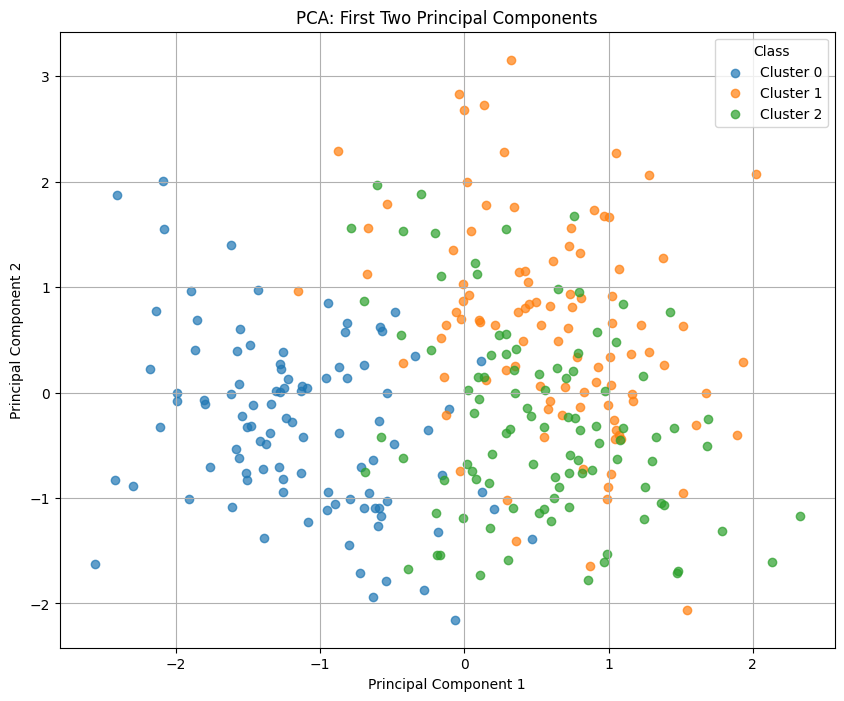

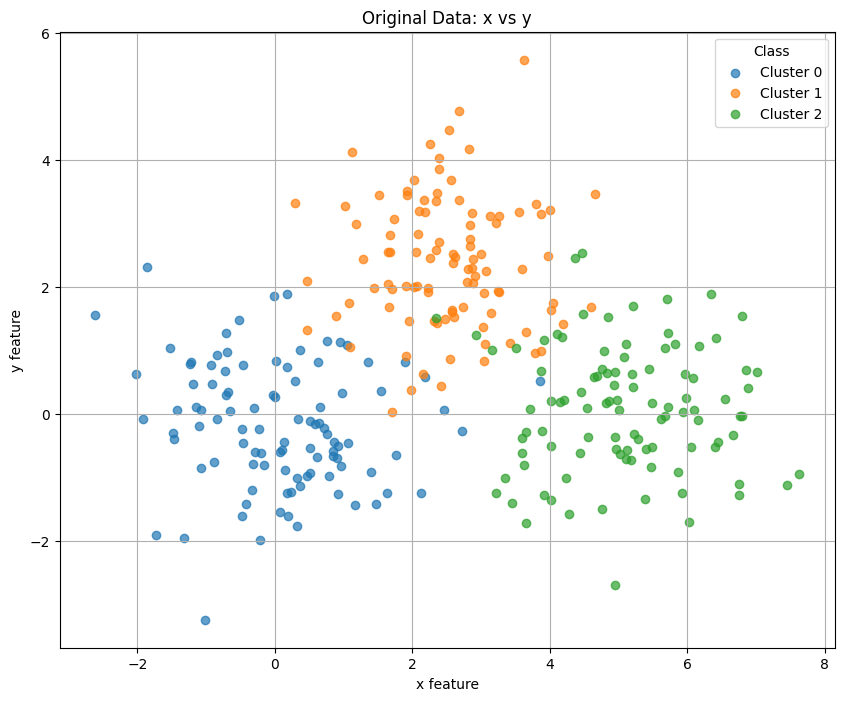

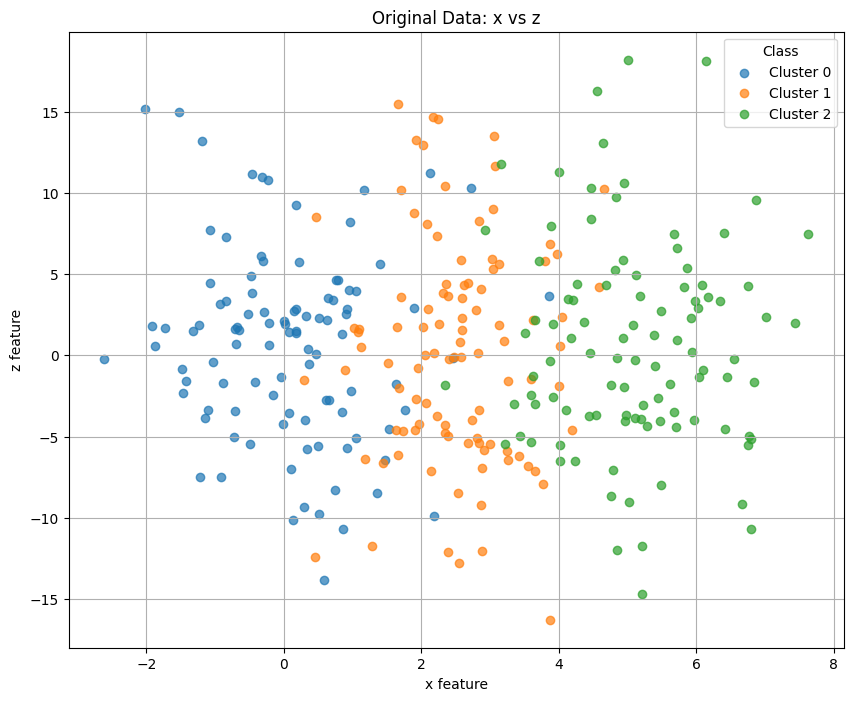

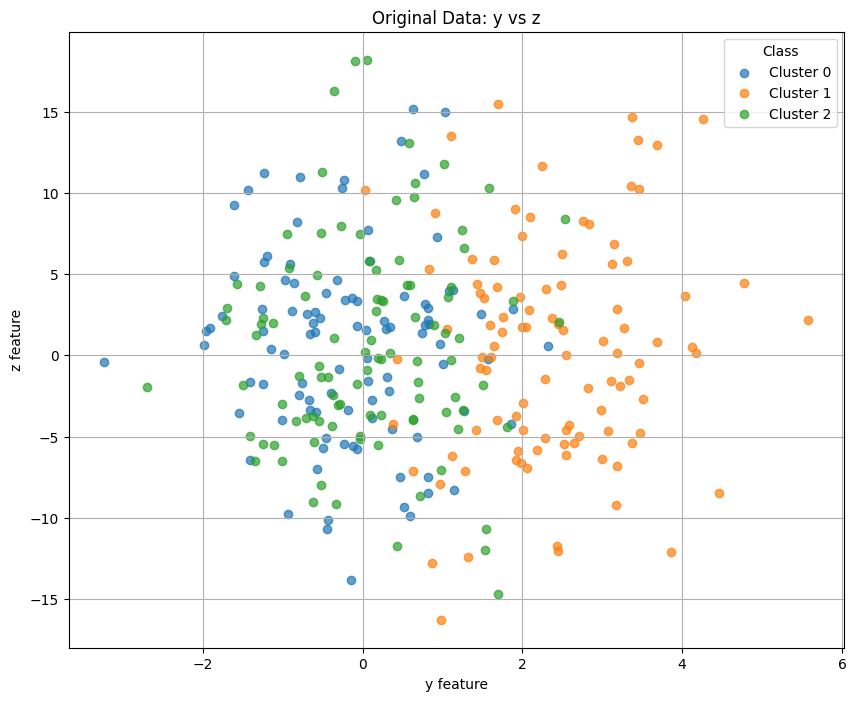

In [14]:
# Plot the PCA results with color coding by class in PCA 2 first components base
plt.figure(figsize=(10, 8))
for i, target_name in enumerate(class_names):
    plt.scatter(XV[y == i, 0], XV[y == i, 1], label=target_name, alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: First Two Principal Components")
plt.legend(title="Class")
plt.grid(True)
plt.show()

# Plot the PCA results with color coding by class in x-y coordinates
plt.figure(figsize=(10, 8))
for i, target_name in enumerate(class_names):
    plt.scatter(x_points[y == i], y_points[y == i], label=target_name, alpha=0.7)

plt.xlabel("x feature")
plt.ylabel("y feature")
plt.title("Original Data: x vs y")
plt.legend(title="Class")
plt.grid(True)
plt.show()

# Plot the PCA results with color coding by class in x-z coordinates
plt.figure(figsize=(10, 8))
for i, target_name in enumerate(class_names):
    plt.scatter(x_points[y == i], z_points[y == i], label=target_name, alpha=0.7)

plt.xlabel("x feature")
plt.ylabel("z feature")
plt.title("Original Data: x vs z")
plt.legend(title="Class")
plt.grid(True)
plt.show()

# Plot the PCA results with color coding by class in y-z coordinates
plt.figure(figsize=(10, 8))
for i, target_name in enumerate(class_names):
    plt.scatter(y_points[y == i], z_points[y == i], label=target_name, alpha=0.7)

plt.xlabel("y feature")
plt.ylabel("z feature")
plt.title("Original Data: y vs z")
plt.legend(title="Class")
plt.grid(True)
plt.show()

**Does PCA improve the separation of data points from different clusters compared to the original feature spaces? Explain why.**

Analizując otrzymane wykresy, można wyciągnąć wniosek, że PCA w rzucie 2D nie zawsze poprawia separację klas w porównaniu do oryginalnych cech (x, y). Przyczyną takiego wyniku może być to, że głównym celem PCA (Principal Component Analysis) jest maksymalizacja wyjaśnianej wariancji, a nie separacja klas. PCA szuka kierunków, w których dane są najbardziej rozciągnięte i rozrzucone, a nie wzdłuż któych występują przerwy pomiędzy grupami punktów.

W analizowanym zbiorze danych obserwujemy także, że każda z trzech głównych składowych ($PC1, PC2, PC3$) wyjaśnia zbliżony procent całkowitej wariancji (odpowiednio 34,72%, 33,44% i 31,84%), zatem odrzucenie trzeciej składowej w celu stworzenia wykresu 2D oznacza utratę aż 1/3 informacji o strukturze danych.

Na wykresie $x-y$ widzimy separację, ponieważ te dwie osie mogą przypadkowo dobrze oddawać różnice między grupami.Na wykresie $PC1-PC2$ klastry mogą się nakładać, ponieważ informacja pozwalająca je rozróżnić została "zepchnięta" do pominiętej składowej $PC3$.

Prawdziwe korzyści z zastosowania PCA przedstawiają wykresy zaprezentowane poniżej, na których punkty znacznie wyraźniej grupują się w osobne klasy na wykresie z osiami ustawionymi wzdłuż kierunków głównych wyznaczonych na podstawie PCA. Wynika to stąd, że w oryginalnej przestrzeni cech klastry mogą być ustawione "niedogodnie" (pod skosem względem osi $x, y, z$). Rzutując je na płaszczyzny, widzimy ich wzajemne przenikanie się. PCA dokonuje takiej rotacji układu współrzędnych, po której nowe osie (składowe główne) są ustawione zgodnie z naturalnymi kierunkami, w których "rozpięte" są dane. W 3D widzimy całą strukturę "od najlepszej strony", pod kątem, który najlepiej eksponuje jej wewnętrzną geometrię, co przy okazji skutkuje wyraźniejszym oddzieleniem klastrów od siebie.

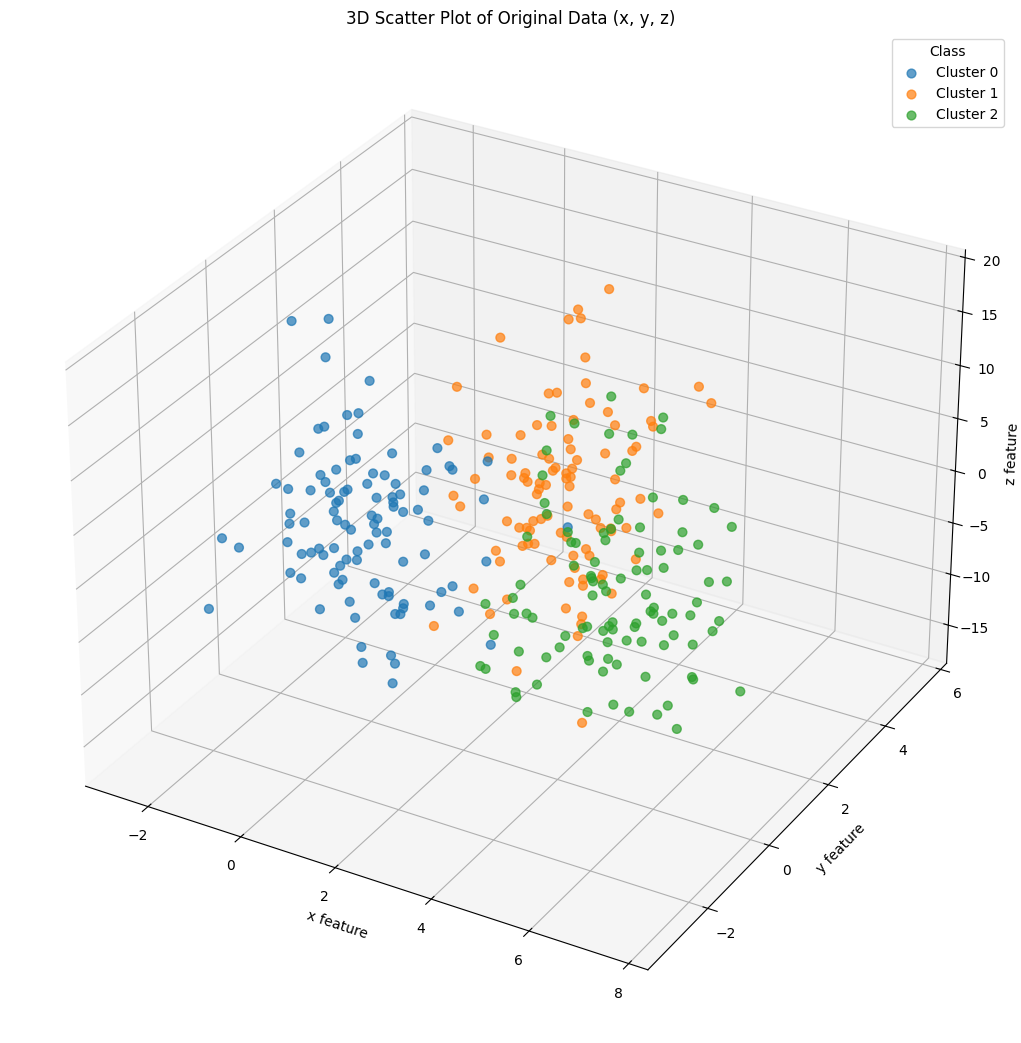

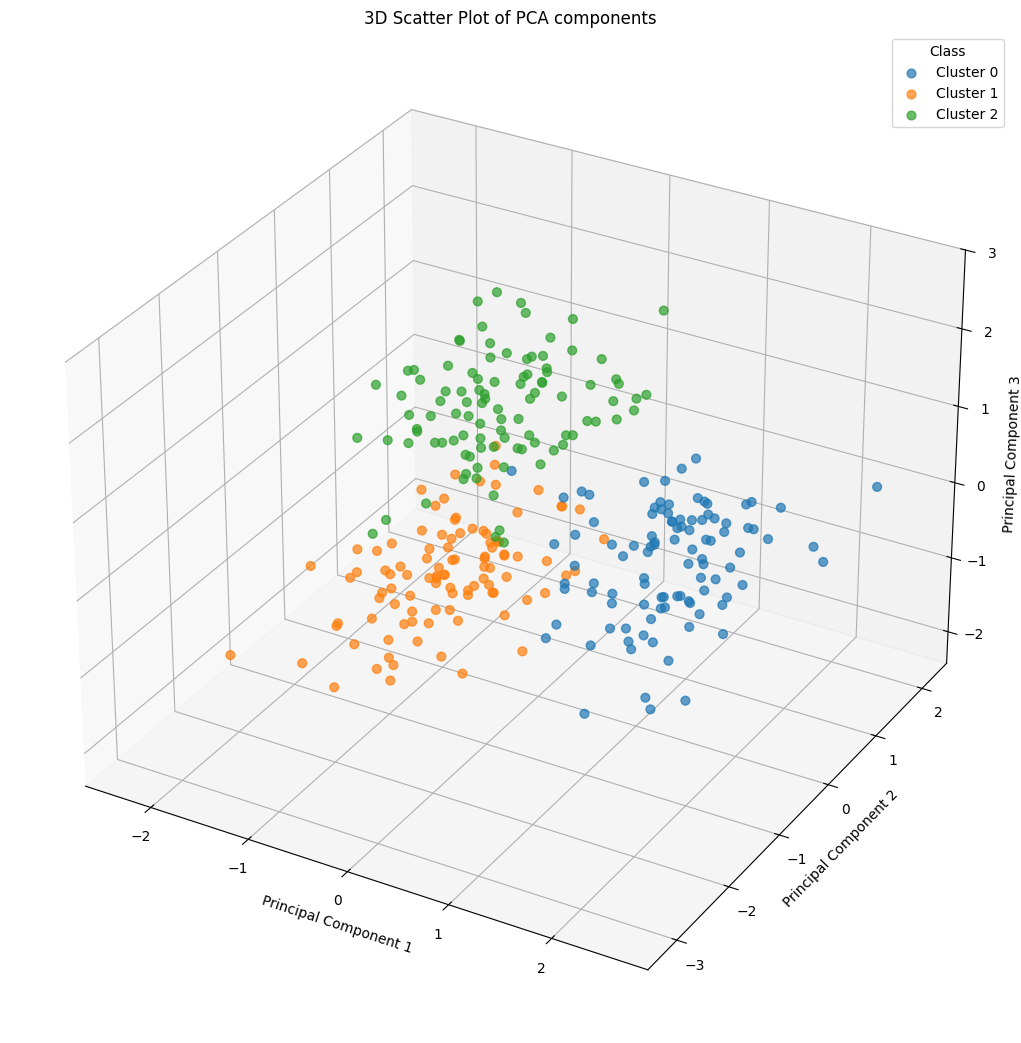

In [15]:
# Tworzę wykres 3D we współrzędnych x-y-z
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Rysuję punkty dla każdej klasy osobno
for i, name in enumerate(class_names):
    ax.scatter(
        x_points[y == i],
        y_points[y == i],
        z_points[y == i],
        label=name,
        s=40,
        alpha=0.7
    )

ax.set_xlabel("x feature")
ax.set_ylabel("y feature")
ax.set_zlabel("z feature")
ax.set_title("3D Scatter Plot of Original Data (x, y, z)")
ax.legend(title="Class")

plt.show()


# Tworzę wykres 3D we współrzędnych PCA
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Rysuję punkty dla każdej klasy osobno
for i, name in enumerate(class_names):
    ax.scatter(
        -XV[y == i, 0],    #odwracam kierunki osi x i y, żeby lepiej było widać rozdzielenie pomiędzy klasami
        -XV[y == i, 1],
        XV[y == i, 2],
        label=name,
        s=40,
        alpha=0.7
    )

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D Scatter Plot of PCA components")
ax.legend(title="Class")

plt.show()

#To generalnie pokazuje, dlaczego PCA pomaga, mimo że powyższe wykresy 2D tego nie pokazywały jasno. Wynika to stąd, że wszystkie składowe PCA dają niemal po równo 1/3 wyjaśnienia obserwowanej wariancji i są niemal tak samo ważne. Na wykresie 3D już wyrażnie widać, że współrzędne otrzymywane z PCA są lepsze niż proste x-y-z

**Dlaczego standardyzacja danych jest niezbędna przed zastosowaniem PCA?**

Standaryzacja danych jest koniecznym etapem poprzedzającym zastosowanie Principal Component Analysis (PCA), ponieważ metoda ta opiera się na analizie wariancji poszczególnych cech. PCA wyszukuje kierunki największej zmienności w danych, a więc cechy o większej wariancji mają silniejszy wpływ na wynik analizy. Jeżeli poszczególne cechy są wyrażone w różnych skalach lub jednostkach, to ich wariancje mogą różnić się o rzędy wielkości, co prowadzi do zniekształcenia wyników PCA.

Brak standaryzacji sprawia, że cechy o największej skali zaczynają dominować nad pozostałymi, niezależnie od ich rzeczywistego znaczenia. Przykładowo, jeśli jedna cecha opisuje wysokość budynku (wyrażoną w metrach), a druga wzrost dozorcy (wyrażony w centymetrach), to typowy zakres zmian pierwszej cechy będzie wielokrotnie większy niż drugiej. W efekcie PCA uzna różnice w wysokości budynków za znacznie ważniejsze niż różnice we wzroście ludzi, ponieważ wariancja pierwszej cechy będzie nieporównywalnie większa. Oznacza to, że główne składowe zostaną skierowane przede wszystkim w stronę cechy o największej skali, a pozostałe cechy zostaną praktycznie pominięte.

Standaryzacja, czyli przekształcenie każdej cechy tak, aby miała średnią równą 0 i odchylenie standardowe równe 1, eliminuje ten problem. Dzięki temu wszystkie cechy są wyrażone w porównywalnej skali, a PCA analizuje rzeczywistą strukturę zależności między cechami, a nie artefakty wynikające z jednostek pomiaru. Standaryzacja zapewnia więc, że
wszystkie cechy są traktowane jako równie ważne, a wynik PCA nie jest zdominowany przez cechy o naturalnie dużej skali. Dzięki temu główne składowe odzwierciedlają faktyczne zależności w danych, a wynik analizy nie jest wrażliwy na różnice jednostek i zakresów wartości.